In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# starts from the repository root or /analytics.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "analytics":
    ANALYTICS_DIR = CURRENT_DIR
else:
    ANALYTICS_DIR = CURRENT_DIR / "analytics"

ANALYTICS_DIR.mkdir(exist_ok=True)

TITANIC_CSV = ANALYTICS_DIR / "titanic.csv"

print("Analytics directory:", ANALYTICS_DIR)

Matplotlib is building the font cache; this may take a moment.


Analytics directory: c:\Code\python\zepto-ai-ml-capstone\analytics


In [2]:
df = sns.load_dataset("titanic")

# Immediately save the raw loaded dataset
df.to_csv(TITANIC_CSV, index=False)

print(f"Titanic dataset saved to: {TITANIC_CSV}")

Titanic dataset saved to: c:\Code\python\zepto-ai-ml-capstone\analytics\titanic.csv


In [3]:
print("DATASET SHAPE")
print(df.shape)

print("\nDATASET INFO")
df.info()

print("\nDESCRIPTIVE STATISTICS")
print(df.describe())

DATASET SHAPE
(891, 15)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

DESCRIPTIVE STATISTICS
         survived      pclass   

In [4]:
missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
)

missing_report = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
    .to_frame(name="missing_percentage")
)

print("Columns containing missing values:")
print(missing_report)

Columns containing missing values:
             missing_percentage
deck                  77.216611
age                   19.865320
embarked               0.224467
embark_town            0.224467


In [5]:
#< 5%        → drop affected rows
#5%–30%      → impute
#> 30%       → explicitly decide drop column / missing category


cleaning_decisions = []

for column, percentage in missing_report["missing_percentage"].items():

    if percentage < 5:
        strategy = "Drop rows containing missing values"

    elif percentage <= 30:
        if pd.api.types.is_numeric_dtype(df[column]):
            strategy = "Impute using median"
        else:
            strategy = "Impute using mode"

    else:
        strategy = "Drop column because missingness is too high for reliable imputation"

    cleaning_decisions.append(
        {
            "column": column,
            "missing_percentage": percentage,
            "strategy": strategy,
        }
    )


cleaning_decisions_df = pd.DataFrame(cleaning_decisions)

print(cleaning_decisions_df.to_string(index=False))

     column  missing_percentage                                                            strategy
       deck           77.216611 Drop column because missingness is too high for reliable imputation
        age           19.865320                                                 Impute using median
   embarked            0.224467                                 Drop rows containing missing values
embark_town            0.224467                                 Drop rows containing missing values


In [6]:
df_clean = df.copy()

# Use the ORIGINAL missing percentages when deciding strategy.
for column, percentage in missing_report["missing_percentage"].items():

    # Under 5% missing -> drop rows
    if percentage < 5:

        df_clean = df_clean.dropna(subset=[column])

    # 5%-30% missing -> impute
    elif percentage <= 30:

        if pd.api.types.is_numeric_dtype(df_clean[column]):

            median_value = df_clean[column].median()

            df_clean[column] = (
                df_clean[column]
                .fillna(median_value)
            )

        else:

            mode_value = df_clean[column].mode()[0]

            df_clean[column] = (
                df_clean[column]
                .fillna(mode_value)
            )

    # Above 30% -> drop column
    else:

        df_clean = df_clean.drop(columns=[column])


df_clean = df_clean.reset_index(drop=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Original shape: (891, 15)
Cleaned shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [7]:
print("CLEANING DECISIONS")
print("=" * 60)

for row in cleaning_decisions:

    print(
        f"{row['column']}: "
        f"{row['missing_percentage']:.2f}% missing -> "
        f"{row['strategy']}"
    )

CLEANING DECISIONS
deck: 77.22% missing -> Drop column because missingness is too high for reliable imputation
age: 19.87% missing -> Impute using median
embarked: 0.22% missing -> Drop rows containing missing values
embark_town: 0.22% missing -> Drop rows containing missing values


### Missing-value handling

Missing-value handling follows the required percentage-based rule. Columns
with less than 5% missing values have their affected rows removed. Columns
with between 5% and 30% missing values are imputed; numeric columns use the
median and categorical columns use the mode.

Any column with more than 30% missing values is dropped because imputing such
a large proportion of its values could introduce unreliable information into
the analysis. The exact measured percentages and resulting decisions are
shown in the output above.

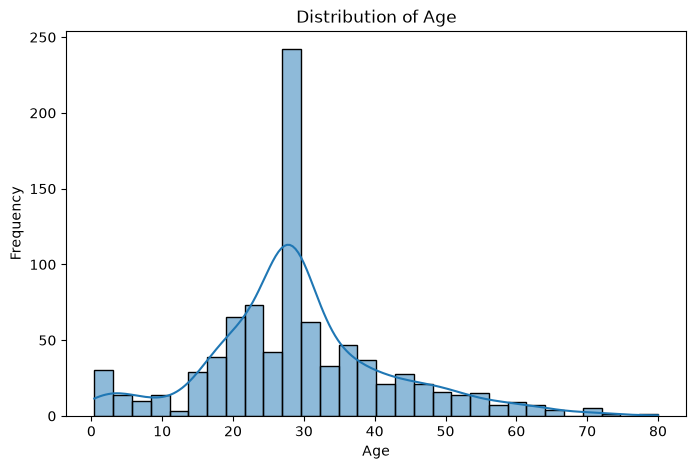

In [9]:
#Univariate analysis
#Age histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30,
    kde=True,
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

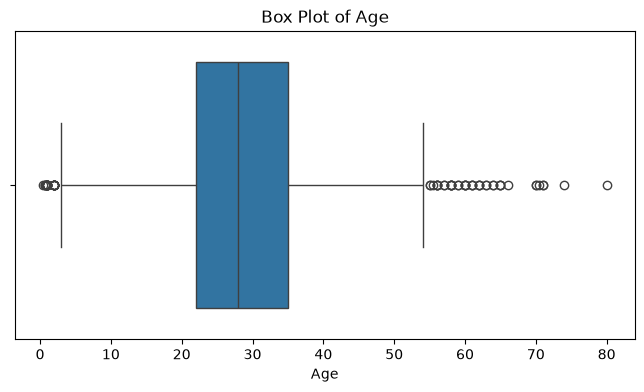

In [10]:
#Age box plot
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_clean,
    x="age",
)

plt.title("Box Plot of Age")
plt.xlabel("Age")

plt.show()

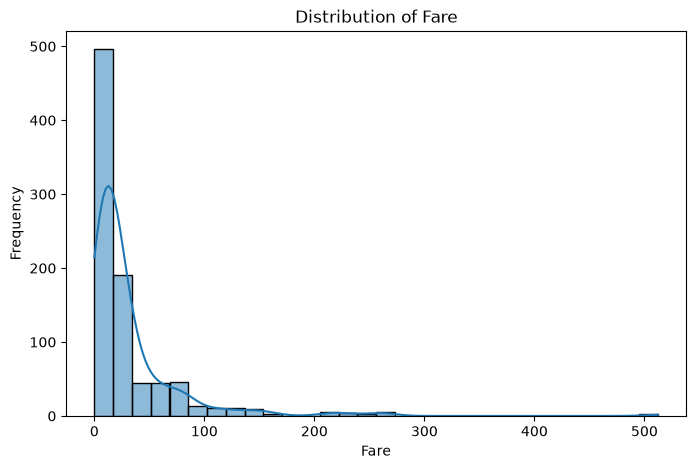

In [11]:
#Fare histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="fare",
    bins=30,
    kde=True,
)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

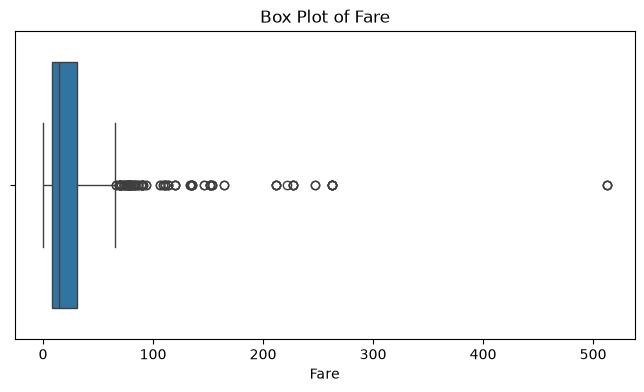

In [13]:
#Fare box plot
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_clean,
    x="fare",
)

plt.title("Box Plot of Fare")
plt.xlabel("Fare")

plt.show()

In [14]:
#IQR outlier calculation
def calculate_iqr_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (series < lower_bound)
        | (series > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(outlier_count),
    }


age_outliers = calculate_iqr_outliers(df_clean["age"])
fare_outliers = calculate_iqr_outliers(df_clean["fare"])

outlier_report = pd.DataFrame(
    {
        "age": age_outliers,
        "fare": fare_outliers,
    }
).T

print(outlier_report)

           Q1    Q3      IQR  Lower Bound  Upper Bound  Outlier Count
age   22.0000  35.0  13.0000       2.5000      54.5000           65.0
fare   7.8958  31.0  23.1042     -26.7605      65.6563          114.0


In [15]:
#Fare mean, median, mode and skew conclusion
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode().iloc[0]

print(f"Fare mean   : {fare_mean:.4f}")
print(f"Fare median : {fare_median:.4f}")
print(f"Fare mode   : {fare_mode:.4f}")


if fare_mean > fare_median > fare_mode:

    fare_distribution = "right-skewed"

elif fare_mean < fare_median < fare_mode:

    fare_distribution = "left-skewed"

else:

    fare_distribution = "not clearly classified by strict mean/median/mode ordering"


print(
    "\nBased on the mean, median and mode ordering, "
    f"the fare distribution is {fare_distribution}."
)

Fare mean   : 32.0967
Fare median : 14.4542
Fare mode   : 8.0500

Based on the mean, median and mode ordering, the fare distribution is right-skewed.


In [16]:
#Task 4 — Bivariate analysis
#Survival by sex using boolean masking

sex_survival_results = []

for sex_value in sorted(df_clean["sex"].dropna().unique()):

    mask = df_clean["sex"] == sex_value

    survival_rate = (
        df_clean.loc[mask, "survived"]
        .mean()
    )

    sex_survival_results.append(
        {
            "sex": sex_value,
            "survival_rate": survival_rate,
        }
    )


sex_survival_df = pd.DataFrame(sex_survival_results)

print(sex_survival_df)

      sex  survival_rate
0  female       0.740385
1    male       0.188908


In [18]:
#Survival by passenger class
pclass_survival_results = []

for class_value in sorted(df_clean["pclass"].unique()):

    mask = df_clean["pclass"] == class_value

    survival_rate = (
        df_clean.loc[mask, "survived"]
        .mean()
    )

    pclass_survival_results.append(
        {
            "pclass": class_value,
            "survival_rate": survival_rate,
        }
    )


pclass_survival_df = pd.DataFrame(pclass_survival_results)

print(pclass_survival_df)

   pclass  survival_rate
0       1       0.626168
1       2       0.472826
2       3       0.242363


In [19]:
#Survival by sex AND pclass
sex_pclass_results = []

for sex_value in sorted(df_clean["sex"].dropna().unique()):

    for class_value in sorted(df_clean["pclass"].unique()):

        mask = (
            (df_clean["sex"] == sex_value)
            &
            (df_clean["pclass"] == class_value)
        )

        survival_rate = (
            df_clean.loc[mask, "survived"]
            .mean()
        )

        sex_pclass_results.append(
            {
                "sex": sex_value,
                "pclass": class_value,
                "survival_rate": survival_rate,
            }
        )


sex_pclass_survival_df = pd.DataFrame(
    sex_pclass_results
)

print(sex_pclass_survival_df)

      sex  pclass  survival_rate
0  female       1       0.967391
1  female       2       0.921053
2  female       3       0.500000
3    male       1       0.368852
4    male       2       0.157407
5    male       3       0.135447


In [20]:
#Exact six-column correlation matrix
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
]

correlation_matrix = (
    df_clean[correlation_columns]
    .corr()
)

print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


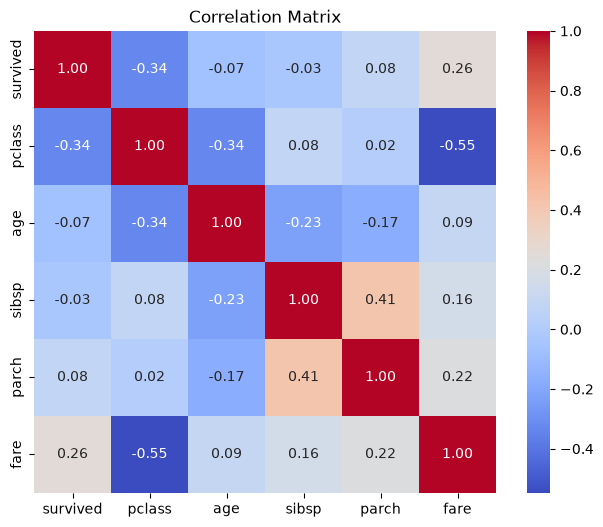

In [21]:
#Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
#Programmatically identify two strongest correlations
upper_triangle_mask = np.triu(
    np.ones(correlation_matrix.shape),
    k=1
).astype(bool)

correlation_pairs = (
    correlation_matrix
    .where(upper_triangle_mask)
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

top_two_correlations = (
    correlation_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .head(2)
    .reset_index(drop=True)
)

print("Two strongest absolute off-diagonal correlations:")
print(top_two_correlations)

Two strongest absolute off-diagonal correlations:
  feature_1 feature_2  correlation  absolute_correlation
0    pclass      fare    -0.548193              0.548193
1     sibsp     parch     0.414542              0.414542


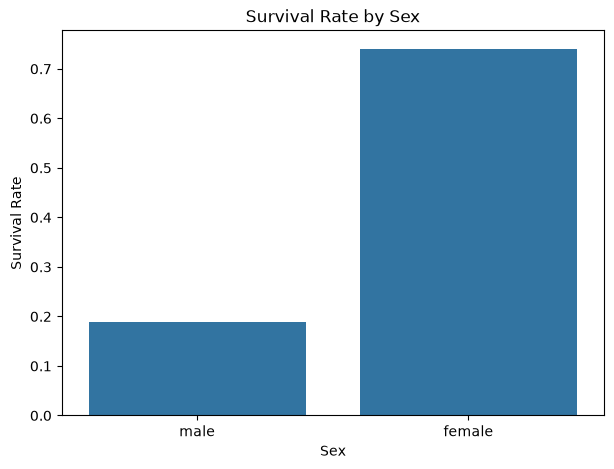

In [23]:
#Task 5 — Four-chart data story
#Survival rate by sex

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="sex",
    y="survived",
    errorbar=None,
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

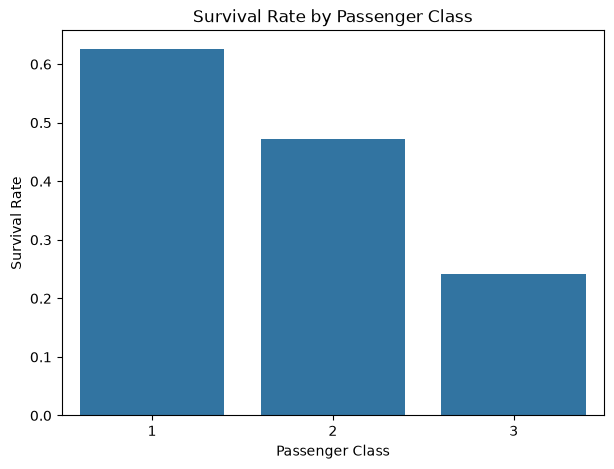

In [24]:
#Survival rate by passenger class
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    errorbar=None,
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

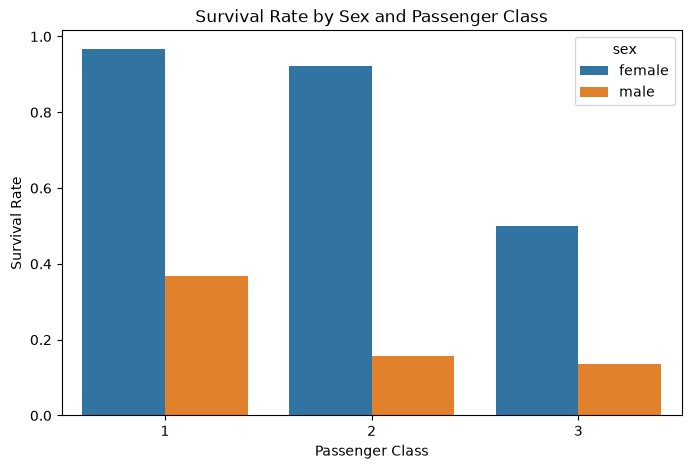

In [25]:
#Survival by sex and passenger class
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None,
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

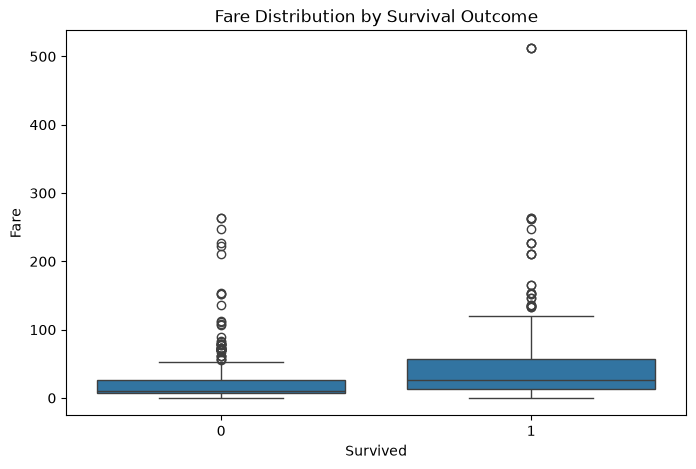

In [26]:
#Fare distribution by survival outcome
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare",
)

plt.title("Fare Distribution by Survival Outcome")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

In [27]:
#Task 6 — EDA-only standardization
#Before scaling

before_scaling = df_clean[
    ["age", "fare"]
].agg(["mean", "std"])

print("Before standardization:")
print(before_scaling)

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504


In [28]:
#Standardize age and fare
eda_scaled = df_clean.copy()

scaler_eda = StandardScaler()

eda_scaled[
    ["age", "fare"]
] = scaler_eda.fit_transform(
    df_clean[["age", "fare"]]
)

print(
    eda_scaled[
        ["age", "fare"]
    ].head()
)

        age      fare
0 -0.563674 -0.500240
1  0.669217  0.788947
2 -0.255451 -0.486650
3  0.438050  0.422861
4  0.438050 -0.484133


In [29]:
#Confirm mean ≈ 0 and std ≈ 1
after_scaling = pd.DataFrame(
    {
        "mean": eda_scaled[
            ["age", "fare"]
        ].mean(),

        "std": eda_scaled[
            ["age", "fare"]
        ].std(ddof=0),
    }
)

print("After standardization:")
print(after_scaling)

After standardization:
              mean  std
age   2.717486e-16  1.0
fare  1.398706e-16  1.0
